# 10 — Where the data comes from

A dataset is not a special kind of thing here. **A source is a node**: it has a
`forward`, and that is the only reason the DSL, `.at()`, `.cached()`, the record
and the figure all reach it. There is no `Source` trait anywhere in the library.

What is different is what the graph is handed. Not a batch — a **coordinate**:

    g.forward({"at": 4096, "take": 64})

The rest of this notebook is why that is worth doing, and what it makes true
that was not true before.

In [1]:
import random
import tempfile
import time

import pyarrow
import pyarrow.parquet

from soma_next import Graph, Node, Store
from soma_next.data import Parquet, settle, to_arrow

## A dataset is bytes in a store

The same `Store` as everywhere else — a directory here, and
`Store.on_bucket(...)` where there is nothing mounted. A name points at a
digest, and the digest is the hash of the content: remember that, because it is
the whole trick further down.

In [2]:
random.seed(0)

SPAM = ["win", "free", "cash", "prize", "claim", "urgent", "winner", "txt"]
HAM = ["dinner", "tomorrow", "bus", "sorry", "meeting", "later", "mum", "ok"]

def message(spam):
    words = SPAM if spam else HAM
    return " ".join(random.choice(words) for _ in range(random.randint(4, 12)))

labels = [1 if random.random() < 0.13 else 0 for _ in range(2000)]
table = pyarrow.table({"sms": [message(one) for one in labels], "label": labels})

sink = pyarrow.BufferOutputStream()
pyarrow.parquet.write_table(table, sink)

where = tempfile.mkdtemp()
store = Store(where)
store.bind("sms/train", store.put(sink.getvalue().to_pybytes()))

table.slice(0, 3).to_pydict()

{'sms': ['mum sorry later bus bus ok bus',
  'mum sorry dinner dinner mum dinner bus tomorrow mum meeting later sorry',
  'later bus later meeting'],
 'label': [0, 0, 0]}

## A source is a node

`Parquet(store, name)` resolves the name and reads **nothing**. A graph that
names a dataset has not opened it — which is the half of a "virtual table" that
is actually worth having.

The figure below is drawn from a graph that has never run, exactly as in
notebook 1. The dataset is a box in it like any other.

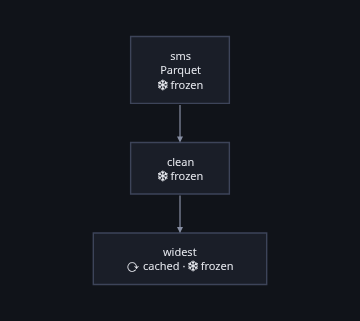

In [3]:
class Clean(Node):
    """Rows in, one list of word counts per message out. No torch here."""

    def __init__(self):
        self.calls = 0

    def forward(self, frame, ctx):
        self.calls += 1
        # `column` hands over plain Python values, so a worker with no dataframe
        # library in it can still read a column. `to_polars` / `to_arrow` are for
        # when there is real work to do on the rows.
        return [
            [float(len(word)) for word in one.split()]
            for one in frame.column("sms")
        ]


class Widest(Node):
    """How long the longest message in the batch was."""

    def __init__(self):
        self.calls = 0

    def forward(self, counts, ctx):
        self.calls += 1
        return float(max(len(one) for one in counts))


clean, widest = Clean(), Widest()
g = Graph.somatize(
    Parquet(store, "sms/train").named("sms").frozen()
    >> clean.named("clean").frozen()
    >> widest.named("widest").frozen().cached()
)
settle(g)
g.figure()

## And it is handed a coordinate

`{"at": 0, "take": 64}` is the input of the graph. What comes out of the source
is a **frame** — Arrow, so `to_polars` or `to_arrow` turn it into whichever
dataframe you have installed, and neither is a dependency of this library.

A short frame means the dataset ended, and one past the end has no rows at all.
That is how somebody walking a dataset finds out they have arrived, without
asking anybody how long it was.

In [4]:
print(g.forward({"at": 0, "take": 64}))
print(g.forward({"at": 1980, "take": 64}), "· the last span is short")

12.0
11.0 · the last span is short


## What the coordinate buys

A cache has to **name** what it is being asked, and everything but the input is
already a name: the node's class, its settled state, its salt. The input is the
one thing it has to look at — all of it — because two batches differing in one
number have to end up with different names.

So a cache weighs the batch, on every step, hit or miss. It is like a library
that reads a whole book to check whether it already has it, instead of looking
at the ISBN.

Below: the same graph, the same cache, the same everything — the input is the
only thing that changes.

In [5]:
import torch

import soma_next.torch  # registers the codec that writes a tensor down


class Constant(Node):
    def forward(self, x, ctx):
        return 1.0


weighed = Graph.somatize(Constant().named("n").frozen().cached())

def milliseconds(what, repeats=15):
    for _ in range(3):
        weighed.forward(what, store=store)
    taken = []
    for _ in range(repeats):
        start = time.perf_counter()
        weighed.forward(what, store=store)
        taken.append((time.perf_counter() - start) * 1e3)
    return sorted(taken)[len(taken) // 2]

from soma_next import Opaque

for name, what in [
    ("a batch of 1 MB", Opaque(torch.randn(262_144))),
    ("a batch of 19 MB (32x3x224x224)", Opaque(torch.randn(32 * 3 * 224 * 224))),
    ("a coordinate", {"at": 0, "take": 64}),
]:
    print(f"{name:>34}: {milliseconds(what):8.3f} ms per forward")

                   a batch of 1 MB:    4.891 ms per forward


   a batch of 19 MB (32x3x224x224):  121.439 ms per forward
                      a coordinate:    0.028 ms per forward


One machine and one afternoon, so read the shape and not the digits: **linear
in the batch, and paid on the hits too** — you pay to ask whether you can
avoid the work. With a coordinate there is nothing to weigh: the rows are named
by the span they are and by the version they came from, and **both are known
before anything is read**.

## And what nobody needs is not computed

A name is knowable **before anything runs**, so the engine asks the store which
of those answers it already has — one question, by name, reading nothing — and
then works backwards from the output: a node whose answer is kept does not need
its inputs.

So on a second run of the same span, `widest` is read back and neither the
dataset nor the tokenizer is touched at all. The record says so out loud, rather
than leaving a hole where a node's time should be.

In [6]:
clean.calls = widest.calls = 0
seen = []

g.forward({"at": 0, "take": 64}, store=where)                        # everything runs
g.forward({"at": 0, "take": 64}, store=where, watching=seen.append)  # and now?

for fact in seen:
    print(fact)

print(f"\nclean ran {clean.calls} time(s), widest {widest.calls}")


{'fact': 'spared', 'node': 'sms'}
{'fact': 'spared', 'node': 'clean'}
{'fact': 'recalled', 'node': 'widest', 'key': 'sha256:c521a013edd2fee9cbd7ca9633ae70574b4427993dfaed01d05e051d462fb3e6'}
{'fact': 'finished', 'took_us': '155'}

clean ran 1 time(s), widest 1


## The version, which the store had already worked out

The other half of that name. A source has to say what it is *without reading
itself*, or it does exactly the work the cache exists to avoid — and against a
store that is free, because a name resolves to a digest and the digest is the
hash of the content.

`settle(g)` is what puts it in the key, and it is the same shape as
`soma_next.torch.freeze(g)`: the graph **declares** that a node's state does not
change, and whoever knows what is inside makes it true. For weights that means
hashing them. Here it means repeating what the store already knew.

In [7]:
source = Parquet(store, "sms/train")
print(source.version)

# Somebody replaces the dataset, under the same name.
half = pyarrow.BufferOutputStream()
pyarrow.parquet.write_table(table.slice(0, 500), half)
store.bind("sms/train", store.put(half.getvalue().to_pybytes()))

print(Parquet(store, "sms/train").version, "· another dataset, another version")

sha256:5f7ac20586dbfd7c53e497e70f5a7523331bd5133f7c07ee0341729bd9c684e3
sha256:7dbadb8bc409ae2b86a89e1a3659327dda0704bf451f920b50efd00d7a6718e6 · another dataset, another version


Without that version in the key, the second dataset would have read the first
one's answer back out of the store and nothing anywhere would have said a word.
It is the one failure a cache must not have, so declaring `.frozen()` and not
settling is **refused before the first node runs** rather than found out from
the wrong rows.

In [8]:
try:
    Graph.somatize(
        Parquet(store, "sms/train").named("sms").frozen()
        >> Widest().named("widest").frozen().cached()
    ).forward({"at": 0, "take": 8}, store=store)
except ValueError as why:
    print(why)

`sms` is declared frozen and has state, and nobody has settled it: the digest of what it is settled at — weights, or the dataset it reads — is what puts it in its key, so without it two different states of `Parquet` would be kept under one name and you would get the other one back. Call `soma_next.torch.freeze(g)` before running — or `soma_next.data.settle(g)` if what it holds is a dataset. Declaring it is this graph's half, making it true belongs to whoever knows how to hash what is inside


## The rows are read here, the work happens over there

A frame is an opaque like a tensor, so it crosses a wire the same way: with a
codec in front of it. That one is Arrow IPC — the buffers as they already are,
with no encoding pass — and it is the second implementor of `Codec` in the
library.

Which means the shape a cluster actually has: the dataset is where the client
is, and the machine with the accelerator is handed rows.

In [9]:
from soma_next import Worker

counts = Widest()
crossing = Graph.somatize(
    Parquet(store, "sms/train").named("sms")
    >> Clean().named("clean").at("w1")
    >> counts.named("widest")
)

worker = Worker.generic(mode="network")
print(crossing.forward({"at": 0, "take": 32}, workers={"w1": worker}))

12.0


## And a stream is the same graph

Nothing above said the dataset was finite, and nothing has to. A span is a
**position**, and a position can be asked for twice: rows 400..500 are the same
rows tomorrow, however much has arrived since. So a source read by span is
settled, and what moves is not its state — it is **which spans exist**.

A source that answers *whatever is newest* is the other thing, and the engine
refuses to cache under it, because its answer cannot be asked for twice. Nobody
wrote that rule for streams: it falls out of `.frozen()` meaning what it always
meant.

Which leaves the sentence this whole slice is about:

> **The difference between training and deploying is how many rows the frame
> brings.**

4096 from a folder of parquet while training, one from a topic in production.
The same graph, the same nodes, the same codec, the same figure, and no second
code path anywhere.